In [5]:
import numpy as np
import scipy.stats as stats
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
# from dynamic_routing_analysis import decoding_utils
# from dynamic_routing_analysis import plot_utils
# from dynamic_routing_analysis import spike_utils

import os
# import pingouin as pg

import matplotlib
import matplotlib.font_manager as fm

matplotlib.rcParams['font.size'] = 8
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
fm.FontProperties().set_family('arial')

%load_ext autoreload
%autoreload 2
%matplotlib inline
# %matplotlib widget

In [6]:
# results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_0/" #context module only
results_path = r"s3://aind-scratch-data/dynamic-routing/decoding/results/cross_temporal_decode_context_all_units_500ms_bins_0/"

In [7]:
session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.272.parquet"
# session_table_path=r"\\allen\programs\mindscope\workgroups\dynamicrouting\Ethan\CO decoding results\session_table_v0.288.naive.parquet"
session_table=pl.read_parquet(session_table_path)

dr_session_list=(
    session_table.filter(
    pl.col('project')=="DynamicRouting",
    # pl.col('project')=="Templeton",
    pl.col('is_production'),
    pl.col('is_annotated'),
    pl.col('issues')==[],
    # pl.col('is_good_behavior').eq(True),
    pl.col('is_engaged').eq(True),
    )['session_id'].to_list()
    )

block_dprime_threshold=1.0

good_behavior_table={
    'session_id':[],
    'n_good_vis_blocks':[],
    'n_good_aud_blocks':[],
}

for sel_session in dr_session_list:
    
    n_good_vis_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_vis_blocks'].to_numpy()[0]>=block_dprime_threshold)
    n_good_aud_blocks=np.sum(session_table.filter(pl.col('session_id') == sel_session)['cross_modality_dprime_aud_blocks'].to_numpy()[0]>=block_dprime_threshold)

    good_behavior_table['session_id'].append(sel_session)
    good_behavior_table['n_good_vis_blocks'].append(n_good_vis_blocks)
    good_behavior_table['n_good_aud_blocks'].append(n_good_aud_blocks)

good_behavior_table=pd.DataFrame(good_behavior_table)
dr_session_list=good_behavior_table.query('n_good_vis_blocks>=2 and n_good_aud_blocks>=2')['session_id'].values

In [8]:
#to save memory loop through each session individually, then save output

sel_structure='context_module'

cross_temporal_decoding_results = {
    'session_id': [],
    'cross_temporal_matrix': []
}

for sel_session in dr_session_list:

    results = (
        pl.scan_parquet(results_path)
        .filter(
            pl.col('structure').eq(sel_structure),
            pl.col('time_aligned_to').eq('stim_start_time'),
            pl.col('session_id').eq(sel_session)
        )
        .with_columns(
            pl.col('bin_center').round(decimals=3),
            pl.col('train_bin_center').round(decimals=3),
            pl.col('test_bin_center').round(decimals=3)
        )
        .sort('bin_center','train_bin_center','test_bin_center')
        .collect()
    )

    #find how many timebins there are
    timebins = results.filter(pl.col('is_cross_temporal') == False).select(pl.col('bin_center')).unique()
    n_timebins = timebins.shape[0]

    #make a matrix to store the cross-temporal results
    cross_temporal_matrix = np.full((n_timebins, n_timebins), np.nan)

    #first get non-cross temporal decoding for each timebin, average across repeats, and add to matrix
    non_cross_temporal_results = results.filter(pl.col('is_cross_temporal') == False)
    for i, timebin in enumerate(timebins['bin_center']):
        mean_result = non_cross_temporal_results.filter(
            (pl.col('bin_center') == timebin) &
            (pl.col('time_aligned_to').eq('stim_start_time'))
        ).select(pl.col('balanced_accuracy_test')).to_numpy().mean()
        cross_temporal_matrix[i, i] = mean_result

    #then get cross temporal decoding for each train-test bin combination, average across repeats, and fill in matrix 
    cross_temporal_results = results.filter(pl.col('is_cross_temporal') == True)
    for i, train_timebin in enumerate(timebins['bin_center']):
        for j, test_timebin in enumerate(timebins['bin_center']):
            if i==j:
                continue
            mean_result = cross_temporal_results.filter(
                (pl.col('train_bin_center') == train_timebin) & 
                (pl.col('test_bin_center') == test_timebin) &
                (pl.col('train_time_aligned_to').eq('stim_start_time')) &
                (pl.col('test_time_aligned_to').eq('stim_start_time'))
            ).select(pl.col('balanced_accuracy_test')).to_numpy().mean()
            cross_temporal_matrix[i, j] = mean_result
    if len(cross_temporal_results) > 0:
        cross_temporal_decoding_results['session_id'].append(sel_session)
        cross_temporal_decoding_results['cross_temporal_matrix'].append(cross_temporal_matrix)

    print(f"Finished processing session: {sel_session}")

Finished processing session: 626791_2022-08-15
Finished processing session: 626791_2022-08-16
Finished processing session: 636766_2023-01-23
Finished processing session: 636766_2023-01-24
Finished processing session: 636766_2023-01-25
Finished processing session: 636766_2023-01-26
Finished processing session: 644864_2023-01-30
Finished processing session: 644864_2023-01-31
Finished processing session: 644864_2023-02-02
Finished processing session: 644866_2023-02-07
Finished processing session: 644866_2023-02-08
Finished processing session: 644866_2023-02-09
Finished processing session: 644866_2023-02-10
Finished processing session: 649943_2023-02-13
Finished processing session: 649943_2023-02-14
Finished processing session: 649943_2023-02-15
Finished processing session: 649943_2023-02-16
Finished processing session: 644867_2023-02-20
Finished processing session: 644867_2023-02-22
Finished processing session: 644867_2023-02-23
Finished processing session: 660023_2023-08-09
Finished proc

In [9]:
# get the mean across sessions

cross_temporal_df = pd.DataFrame({
    'session_id': cross_temporal_decoding_results['session_id'],
    'cross_temporal_matrix': cross_temporal_decoding_results['cross_temporal_matrix']
})
cross_temporal_df['length']=cross_temporal_df['cross_temporal_matrix'].apply(len)

mean_cross_temporal_matrix = np.nanmean(np.stack(cross_temporal_df.query('length>0')['cross_temporal_matrix']), axis=0)

binsize = np.round(timebins['bin_center'].diff().mean(), 3)


In [10]:
# cross_temporal_df.query('cross_temporal_matrix.shape!=0')

Text(0, 0.5, 'Train Timebin (s)')

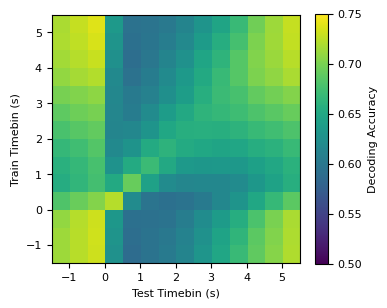

In [11]:
#plot heatmap
fig,ax = plt.subplots(figsize=(4,3.25))
im = ax.imshow(mean_cross_temporal_matrix, aspect='equal', origin='lower', cmap='viridis',vmin=0.5,vmax=0.75,
               extent=[timebins['bin_center'].min()-binsize/2, timebins['bin_center'].max()+binsize/2, 
                       timebins['bin_center'].min()-binsize/2, timebins['bin_center'].max()+binsize/2])
fig.colorbar(im, ax=ax, label='Decoding Accuracy')
ax.set_xlabel('Test Timebin (s)')
ax.set_ylabel('Train Timebin (s)')


In [14]:
timebins


bin_center
f64
-1.25
-0.75
-0.25
0.25
0.75
…
3.25
3.75
4.25


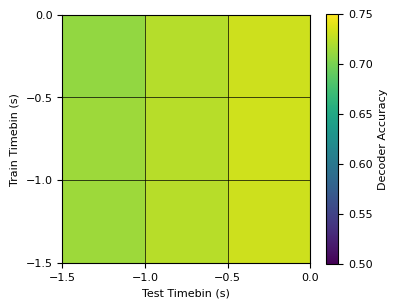

In [22]:
#plot select timepoints

min_timebin=-1.5
max_timebin=0

timebins_array=timebins['bin_center'].to_numpy()

timebin_indices=np.where((timebins_array>=min_timebin) & (timebins_array<=max_timebin))[0]

sel_timebins=timebins_array[timebin_indices]
sub_matrix=mean_cross_temporal_matrix[np.ix_(timebin_indices,timebin_indices)]

fig,ax = plt.subplots(figsize=(4,3.25))
im = ax.imshow(sub_matrix, aspect='equal', origin='lower', vmin=0.5, vmax = 0.75,
               extent=[sel_timebins[0]-binsize/2, sel_timebins[-1]+binsize/2, 
                       sel_timebins[0]-binsize/2, sel_timebins[-1]+binsize/2])
ax.vlines([-1,-0.5], ymin=-1.5, ymax=0,color='k', linewidth=0.5)
ax.hlines([-1,-0.5], xmin=-1.5, xmax=0,color='k', linewidth=0.5)
fig.colorbar(im, ax=ax, label='Decoder Accuracy')
ax.set_xlabel('Test Timebin (s)')
ax.set_ylabel('Train Timebin (s)')
ax.set_xticks([-1.5, -1, -0.5, 0])
ax.set_yticks([-1.5, -1, -0.5, 0])